In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split

# CHANGE THIS to the folder on your laptop
base_root = r"D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset"

print("Inside DATASET:", os.listdir(base_root))

# Since train.csv and test.csv are missing, we dynamically construct
# the dataframe by parsing the dataset directory folders!
data = []
for file_path in glob.glob(os.path.join(base_root, "*", "*.mp4")):
    # Extract the label from the parent directory
    label_dir = os.path.basename(os.path.dirname(file_path))
    # Standardize label if required 
    label = label_dir.lower().replace(" ", "")
    # Emulate the Kaggle format relative path (e.g., normal/Normal_Videos_196.mp4)
    video_name = os.path.relpath(file_path, base_root)
    data.append({"label": label, "video_name": video_name})

# Catch any raw .avi files if present
for file_path in glob.glob(os.path.join(base_root, "*", "*.avi")):
    label_dir = os.path.basename(os.path.dirname(file_path))
    label = label_dir.lower().replace(" ", "")
    video_name = os.path.relpath(file_path, base_root)
    data.append({"label": label, "video_name": video_name})

full_df = pd.DataFrame(data)

# Perform a clean 80-20 Train/Test split identical to original logic
if len(full_df) > 0:
    train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['label'])
    # Reset indices to clean up the DataFrames
    train_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)
else:
    train_df = pd.DataFrame(columns=["label", "video_name"])
    test_df = pd.DataFrame(columns=["label", "video_name"])

print("DATA LOADED AND SPLIT SUCCESSFULLY!")
print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)
print("\nTrain Head:\n", train_df.head())


Inside DATASET: ['abuse', 'arrest', 'arson', 'assault', 'burglary', 'explosion', 'fighting', 'normal', 'road accidents', 'robbery', 'shooting', 'shop lifting', 'stealing', 'vandalism']
DATA LOADED AND SPLIT SUCCESSFULLY!
Train shape: (760, 2) | Test shape: (190, 2)

Train Head:
          label                            video_name
0      robbery           robbery\Robbery004_x264.mp4
1  shoplifting  shop lifting\Shoplifting009_x264.mp4
2    vandalism       vandalism\Vandalism011_x264.mp4
3      robbery           robbery\Robbery007_x264.mp4
4      robbery           robbery\Robbery106_x264.mp4


# Preprocessing

## Exploratory Data Analysis:
Check the shapes, plot the distribution, extract metadata, read inference

In [3]:
# Basic info
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("\nFirst few rows:")
print(train_df.head())

Train shape: (760, 2)
Test shape: (190, 2)

Train columns: ['label', 'video_name']

First few rows:
         label                            video_name
0      robbery           robbery\Robbery004_x264.mp4
1  shoplifting  shop lifting\Shoplifting009_x264.mp4
2    vandalism       vandalism\Vandalism011_x264.mp4
3      robbery           robbery\Robbery007_x264.mp4
4      robbery           robbery\Robbery106_x264.mp4


In [4]:
# Check label column
print("\nClass distribution:")
print(train_df['video_name'].value_counts())


Class distribution:
video_name
normal\Normal_Videos473_x264.mp4        1
robbery\Robbery004_x264.mp4             1
shop lifting\Shoplifting009_x264.mp4    1
vandalism\Vandalism011_x264.mp4         1
robbery\Robbery007_x264.mp4             1
                                       ..
abuse\Abuse035_x264.mp4                 1
robbery\Robbery145_x264.mp4             1
burglary\Burglary035_x264.mp4           1
robbery\Robbery021_x264.mp4             1
robbery\Robbery140_x264.mp4             1
Name: count, Length: 760, dtype: int64



Missing values:
label         0
video_name    0
dtype: int64


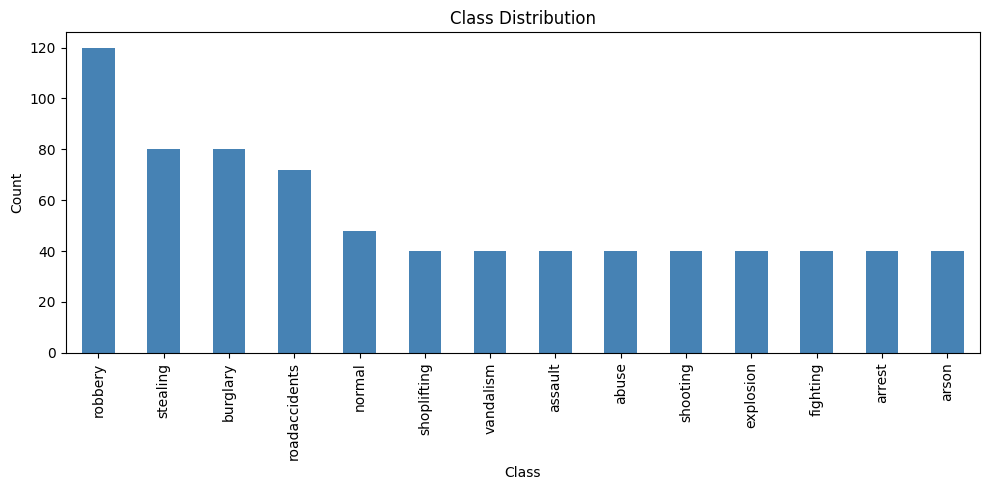

In [5]:
# Check for nulls
print("\nMissing values:")
print(train_df.isnull().sum())

# Visualize class distribution
import matplotlib.pyplot as plt
train_df['label'].value_counts().plot(kind='bar', color='steelblue', figsize=(10,5))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

## Initial Analysis

### Task
Design an AI powered video survelliance system that analyzes real-time CCTV footages to detect and classify unusual events such as violence

### Dataset inference
- mp4 videos of CCTV footages
- Dataset contains 14 different labels, including 13 unusual events
- More detains below

In [6]:
selected_cols = ['label', 'video_name']
train_df = train_df[selected_cols]
test_df = test_df[selected_cols]

total_df = pd.concat([train_df, test_df])
total_df.reset_index(drop = True, inplace = True)
total_df['label'].value_counts()

label
robbery          150
stealing         100
burglary         100
roadaccidents     90
normal            60
shoplifting       50
vandalism         50
assault           50
abuse             50
shooting          50
explosion         50
fighting          50
arrest            50
arson             50
Name: count, dtype: int64

## Proposed approach: 
- We manually watched some videos to understand the dataset in a deeper level
- We found that in the anomaly videos, it's not the entire video that contains anomaly, but a few frames.
- Here is the approach we came up with:

## Visualize random frames

Displaying frames from: D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\robbery\Robbery027_x264.mp4


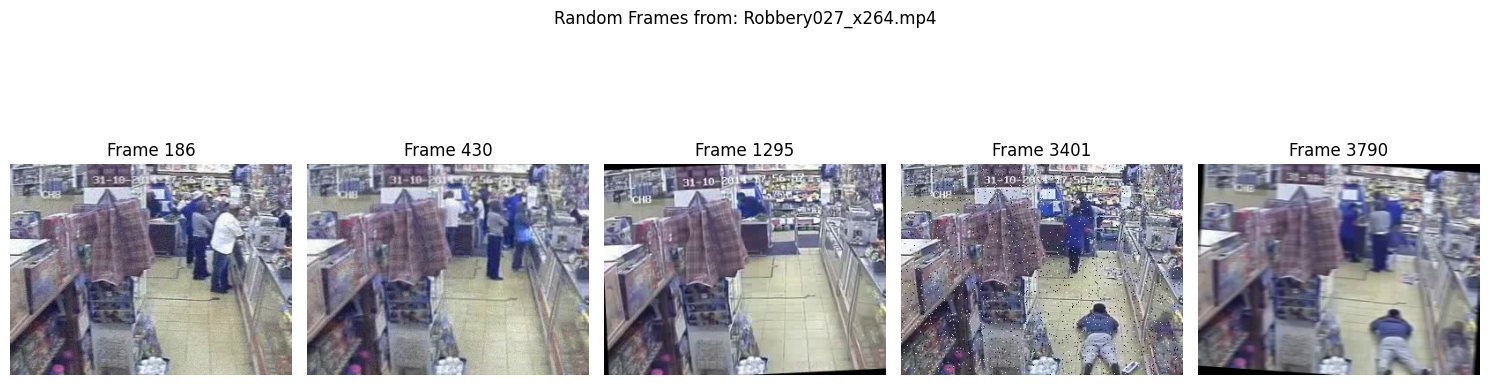

In [7]:
import cv2
import random
import matplotlib.pyplot as plt
import os
import glob

def display_random_frames(video_path, num_frames=5, figsize=(15, 5)):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        print(f"Error: No frames found in video {video_path}")
        cap.release()
        return

    # Select random frame indices
    frame_indices = sorted(random.sample(range(total_frames), min(num_frames, total_frames)))

    plt.figure(figsize=figsize)
    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            plt.subplot(1, num_frames, i + 1)
            plt.imshow(frame_rgb)
            plt.title(f"Frame {frame_idx}")
            plt.axis('off')
        else:
            print(f"Warning: Could not read frame {frame_idx} from {video_path}")

    plt.tight_layout()
    plt.suptitle(f"Random Frames from: {os.path.basename(video_path)}", y=1.02)
    plt.show()
    cap.release()

# CHANGE THIS if your base path is different, but this matches the previous cell
base_root = r"D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset"

# 1. Grab all video files directly from subdirectories
all_videos = []
if os.path.exists(base_root):
    for file_path in glob.glob(os.path.join(base_root, "*", "*.mp4")):
        all_videos.append(file_path)
    for file_path in glob.glob(os.path.join(base_root, "*", "*.avi")):
        all_videos.append(file_path)

# 2. Get a random video path and display
if all_videos:
    random_video_path = random.choice(all_videos)
    print(f"Displaying frames from: {random_video_path}")
    display_random_frames(random_video_path, num_frames=5)
else:
    print(f"No videos found inside '{base_root}'. Please verify your paths.")


## Extracting metadata
Let's understand the dataset more thoroughly

In [8]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

def create_manifest(base_path):
    data = []
    # UCF-Crime structure: base_path/Class_Name/Video_Name.mp4
    classes = [d for d in os.listdir(base_root) if os.path.isdir(os.path.join(base_root, d))]
    
    for cls in classes:
        class_path = os.path.join(base_root, cls)
        videos = [f for f in os.listdir(class_path) if f.endswith(('.mp4', '.avi'))]
        
        print(f"Processing class: {cls}")
        for vid in tqdm(videos):
            vid_path = os.path.join(class_path, vid)
            cap = cv2.VideoCapture(vid_path)
            
            if not cap.isOpened():
                continue # Skip corrupt files
                
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            cap.release()
            
            # Map anomaly to 1, normal to 0 for the Binary MVP
            label = 0 if cls.lower() == 'normal' else 1
            
            data.append({
                'video_path': vid_path,
                'class_name': cls,
                'label': label,
                'total_frames': frame_count,
                'fps': fps,
                'segment_size': frame_count // 32
            })
            
    df = pd.DataFrame(data)
    df.to_csv('video_manifest.csv', index=False)
    return df

# Execute
df = create_manifest(base_root)
print(df.head())

Processing class: abuse


100%|██████████| 50/50 [00:01<00:00, 30.30it/s]


Processing class: arrest


100%|██████████| 50/50 [00:01<00:00, 30.74it/s]


Processing class: arson


...

Processing class: stealing


100%|██████████| 100/100 [00:01<00:00, 62.94it/s]


Processing class: vandalism


100%|██████████| 50/50 [00:01<00:00, 36.44it/s]

                                          video_path class_name  label  \
0  D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...      abuse      1   
1  D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...      abuse      1   
2  D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...      abuse      1   
3  D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...      abuse      1   
4  D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...      abuse      1   

   total_frames   fps  segment_size  
0          2729  30.0            85  
1           865  30.0            27  
2          3699  30.0           115  
3         16794  30.0           524  
4           949  30.0            29  


#### EDA on metadata

In [9]:
df.head(10)

,video_path,class_name,label,total_frames,fps,segment_size
0,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,2729,30.0,85
1,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,865,30.0,27
2,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,3699,30.0,115
3,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,16794,30.0,524
4,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,949,30.0,29
5,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,4380,30.0,136
6,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,1150,30.0,35
7,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,8406,30.0,262
8,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,1001,30.0,31
9,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\abuse\Abu...,abuse,1,1133,30.0,35


In [10]:
df.tail(10)

,video_path,class_name,label,total_frames,fps,segment_size
940,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,4868,30.0,152
941,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,3596,30.0,112
942,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,3243,30.0,101
943,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,4605,30.0,143
944,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,4358,30.0,136
945,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,2099,30.0,65
946,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,2483,30.0,77
947,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,7183,30.0,224
948,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,7999,30.0,249
949,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\vandalism...,vandalism,1,899,30.0,28


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_path    950 non-null    object 
 1   class_name    950 non-null    object 
 2   label         950 non-null    int64  
 3   total_frames  950 non-null    int64  
 4   fps           950 non-null    float64
 5   segment_size  950 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 44.7+ KB


In [12]:
df.nsmallest(5, 'total_frames')

,video_path,class_name,label,total_frames,fps,segment_size
486,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\road acci...,road accidents,1,104,30.0,3
523,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\road acci...,road accidents,1,117,30.0,3
186,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\assault\A...,assault,1,137,30.0,4
480,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\road acci...,road accidents,1,155,30.0,4
502,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\road acci...,road accidents,1,187,30.0,5


In [13]:
df.nlargest(5, 'total_frames')

,video_path,class_name,label,total_frames,fps,segment_size
416,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\normal\No...,normal,0,976503,30.0,30515
344,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\explosion...,explosion,1,141900,30.0,4434
117,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\arson\Ars...,arson,1,126553,30.0,3954
442,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\normal\No...,normal,0,73025,30.0,2282
424,D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\normal\No...,normal,0,66925,30.0,2091


## Inference from current data gathered
Highly imbalanced, while some videos are barely 100 frames, there are almost 1 million frames in few. This shows a very imbalanced dataset. We can't proceed with traditional methodology.

# Feature Extraction and Modelling
using a 3d convolutional model pretrained on rgb imagenet

## -Initial approach (discarded)-
initially we decided to use a visual transformer to extract frames and use CNN(resnet) +LSTM for modelling, but LSTM have short sequence length making it unfit for the task considering the video stats

## New Approach
- We use Multiple Instance Learning (Industry standard for video tasks)
- We use the 3d conv model (I3d inceptionV3 trained on rgb_net) for MIL (feature extraction: 32 segments per video) This is the most time taking task.
- Using the extracted features we train the model. The model will be a small MLP that would not take much time to train.

In [14]:
## manually writing model and importing pretrained weights because we cannot find a pretrained model that can be imported to Kaggle

import torch
import torch.nn as nn
import torch.nn.functional as F

class MaxPool3dPad(nn.Module):
    def __init__(self, kernel_size, stride, padding=None):
        super(MaxPool3dPad, self).__init__()
        if padding is None:
            padding = [k // 2 for k in kernel_size]
        self.pad = nn.ConstantPad3d(padding, 0)
        self.pool = nn.MaxPool3d(kernel_size, stride, 0)

    def forward(self, x):
        return self.pool(self.pad(x))

class Unit3d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(1,1,1), stride=(1,1,1), activation_fn=F.relu, use_batch_norm=True, use_bias=False, name='unit_3d'):
        super(Unit3d, self).__init__()
        padding = [k // 2 for k in kernel_size]
        self._out_channels = out_channels
        self._activation_fn = activation_fn
        self._use_batch_norm = use_batch_norm
        self._name = name
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size, stride, padding=tuple(padding), bias=use_bias)
        if self._use_batch_norm:
            self.bn = nn.BatchNorm3d(out_channels, eps=1e-3, momentum=0.01)

    def forward(self, x):
        x = self.conv(x)
        if self._use_batch_norm:
            x = self.bn(x)
        if self._activation_fn is not None:
            x = self._activation_fn(x)
        return x

class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels, name):
        super(InceptionModule, self).__init__()
        self.b0 = Unit3d(in_channels, out_channels[0], kernel_size=[1,1,1], name=name+'/Branch_0/Conv3d_0a_1x1')
        self.b1a = Unit3d(in_channels, out_channels[1], kernel_size=[1,1,1], name=name+'/Branch_1/Conv3d_0a_1x1')
        self.b1b = Unit3d(out_channels[1], out_channels[2], kernel_size=[3,3,3], name=name+'/Branch_1/Conv3d_0b_3x3')
        self.b2a = Unit3d(in_channels, out_channels[3], kernel_size=[1,1,1], name=name+'/Branch_2/Conv3d_0a_1x1')
        self.b2b = Unit3d(out_channels[3], out_channels[4], kernel_size=[3,3,3], name=name+'/Branch_2/Conv3d_0b_3x3')
        self.b3a = MaxPool3dPad(kernel_size=[3,3,3], stride=[1,1,1], padding=(1,1,1,1,1,1))
        self.b3b = Unit3d(in_channels, out_channels[5], kernel_size=[1,1,1], name=name+'/Branch_3/Conv3d_0b_1x1')

    def forward(self, x):
        b0 = self.b0(x)
        b1 = self.b1b(self.b1a(x))
        b2 = self.b2b(self.b2a(x))
        b3 = self.b3b(self.b3a(x))
        return torch.cat([b0, b1, b2, b3], 1)

class InceptionI3d(nn.Module):
    def __init__(self, num_classes=400, in_channels=3):
        super(InceptionI3d, self).__init__()
        self.conv3d_1a_7x7 = Unit3d(in_channels, 64, kernel_size=[7,7,7], stride=[2,2,2], name='Conv3d_1a_7x7')
        self.maxPool3d_2a_3x3 = MaxPool3dPad(kernel_size=[1,3,3], stride=[1,2,2], padding=(0,0,1,1,1,1))
        self.conv3d_2b_1x1 = Unit3d(64, 64, kernel_size=[1,1,1], name='Conv3d_2b_1x1')
        self.conv3d_2c_3x3 = Unit3d(64, 192, kernel_size=[3,3,3], name='Conv3d_2c_3x3')
        self.maxPool3d_3a_3x3 = MaxPool3dPad(kernel_size=[1,3,3], stride=[1,2,2], padding=(0,0,1,1,1,1))
        self.mixed_3b = InceptionModule(192, [64, 96, 128, 16, 32, 32], 'Mixed_3b')
        self.mixed_3c = InceptionModule(256, [128, 128, 192, 32, 96, 64], 'Mixed_3c')
        self.maxPool3d_4a_3x3 = MaxPool3dPad(kernel_size=[3,3,3], stride=[2,2,2], padding=(0,0,1,1,1,1))
        self.mixed_4b = InceptionModule(480, [192, 96, 208, 16, 48, 64], 'Mixed_4b')
        self.mixed_4c = InceptionModule(512, [160, 112, 224, 24, 64, 64], 'Mixed_4c')
        self.mixed_4d = InceptionModule(512, [128, 128, 256, 24, 64, 64], 'Mixed_4d')
        self.mixed_4e = InceptionModule(512, [112, 144, 288, 32, 64, 128], 'Mixed_4e')
        self.mixed_4f = InceptionModule(592, [256, 160, 320, 32, 128, 128], 'Mixed_4f')
        self.maxPool3d_5a_2x2 = MaxPool3dPad(kernel_size=[2,2,2], stride=[2,2,2], padding=(0,0,0,0,0,0))
        self.mixed_5b = InceptionModule(832, [256, 160, 320, 32, 128, 128], 'Mixed_5b')
        self.mixed_5c = InceptionModule(832, [384, 192, 384, 48, 128, 128], 'Mixed_5c') # Corrected input channels from 1024 to 832
        self.avg_pool = nn.AdaptiveAvgPool3d((1, 1, 1)) # Forces output to (B, 1024, 1, 1, 1)

    def forward(self, x):
        for module in self.children():
            if module == self.avg_pool:
                break
            x = module(x)

        x = self.avg_pool(x)
        return x

**Downloading the pretrained weights of rgb imagenet**

In [15]:
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(repo_id="CarrotBu/I3d", filename="rgb_imagenet.pt")

print(f"Weights downloaded to: {weights_path}")

c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Weights downloaded to: C:\Users\ACER\.cache\huggingface\hub\models--CarrotBu--I3d\snapshots\053e16f1000e60c42f935da17e52817a352df296\rgb_imagenet.pt


In [16]:
device =  torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def load_i3d_features(model, weights_path):
    checkpoint = torch.load(weights_path, map_location=device)
    
    # Filter out the 'logits' layers since we only want features
    # And handle 'module.' prefix if it exists
    cleaned_state_dict = {}
    for k, v in checkpoint.items():
        name = k.replace('module.', '')
        if 'logits' not in name:
            cleaned_state_dict[name] = v
            
    # strict=False allows us to load the backbone even if the 
    # checkpoint has layers our feature-only class doesn't
    msg = model.load_state_dict(cleaned_state_dict, strict=False)
    print(f"Load Status: {msg}")
    return model

# Initialize and Load
i3d = InceptionI3d(num_classes=400, in_channels=3).to(device) #.cuda() for kaggle
i3d = load_i3d_features(i3d, weights_path)
i3d.eval()

Load Status: _IncompatibleKeys(missing_keys=['conv3d_1a_7x7.conv.weight', 'conv3d_1a_7x7.bn.weight', 'conv3d_1a_7x7.bn.bias', 'conv3d_1a_7x7.bn.running_mean', 'conv3d_1a_7x7.bn.running_var', 'conv3d_2b_1x1.conv.weight', 'conv3d_2b_1x1.bn.weight', 'conv3d_2b_1x1.bn.bias', 'conv3d_2b_1x1.bn.running_mean', 'conv3d_2b_1x1.bn.running_var', 'conv3d_2c_3x3.conv.weight', 'conv3d_2c_3x3.bn.weight', 'conv3d_2c_3x3.bn.bias', 'conv3d_2c_3x3.bn.running_mean', 'conv3d_2c_3x3.bn.running_var', 'mixed_3b.b0.conv.weight', 'mixed_3b.b0.bn.weight', 'mixed_3b.b0.bn.bias', 'mixed_3b.b0.bn.running_mean', 'mixed_3b.b0.bn.running_var', 'mixed_3b.b1a.conv.weight', 'mixed_3b.b1a.bn.weight', 'mixed_3b.b1a.bn.bias', 'mixed_3b.b1a.bn.running_mean', 'mixed_3b.b1a.bn.running_var', 'mixed_3b.b1b.conv.weight', 'mixed_3b.b1b.bn.weight', 'mixed_3b.b1b.bn.bias', 'mixed_3b.b1b.bn.running_mean', 'mixed_3b.b1b.bn.running_var', 'mixed_3b.b2a.conv.weight', 'mixed_3b.b2a.bn.weight', 'mixed_3b.b2a.bn.bias', 'mixed_3b.b2a.bn.runn

C:\Users\ACER\AppData\Local\Temp\ipykernel_28048\482785465.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location=device)


InceptionI3d(
  (conv3d_1a_7x7): Unit3d(
    (conv): Conv3d(3, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
    (bn): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  )
  (maxPool3d_2a_3x3): MaxPool3dPad(
    (pad): ConstantPad3d(padding=(0, 0, 1, 1, 1, 1), value=0)
    (pool): MaxPool3d(kernel_size=[1, 3, 3], stride=[1, 2, 2], padding=0, dilation=1, ceil_mode=False)
  )
  (conv3d_2b_1x1): Unit3d(
    (conv): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
    (bn): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  )
  (conv3d_2c_3x3): Unit3d(
    (conv): Conv3d(64, 192, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (bn): BatchNorm3d(192, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  )
  (maxPool3d_3a_3x3): MaxPool3dPad(
    (pad): ConstantPad3d(padding=(0, 0, 1, 1, 1, 1), value=0)
    (pool): MaxPool3d(kernel_size=[1, 

In [17]:
# Check if the manually defined model has worked

# (Batch: 1, Channels: 3, Time: 16, Height: 224, Width: 224)
dummy_input = torch.randn(1, 3, 16, 224, 224).to(device)
with torch.no_grad():
    features = i3d(dummy_input)

print(f"Feature shape: {features.shape}") 
# Expected: [1, 1024, 1, 1, 1]

Feature shape: torch.Size([1, 1024, 1, 1, 1])


In [18]:
import os
import torch
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm

def load_i3d_backbone(model, weights_path):
    # Load weights onto GPU
    checkpoint = torch.load(weights_path, map_location= device)
    
    # Standardize keys (handling 'module.' from DataParallel)
    cleaned_state_dict = {}
    for k, v in checkpoint.items():
        name = k.replace('module.', '')
        # Only keep weights that exist in our backbone definition
        if name in model.state_dict() and 'logits' not in name:
            cleaned_state_dict[name] = v
            
    model.load_state_dict(cleaned_state_dict, strict=False)
    model.to(device).eval()
    return model

def extract_features_from_video(video_path, model, num_segments=32, frames_per_seg=16):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < frames_per_seg:
        cap.release()
        return None 

    seg_size = total_frames / num_segments
    segment_tensors = []

    # 1. Read all segments first (CPU work)
    for i in range(num_segments):
        center_idx = int((i * seg_size) + (seg_size / 2))
        start_frame = max(0, center_idx - (frames_per_seg // 2))
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        frames = []
        for _ in range(frames_per_seg):
            ret, frame = cap.read()
            if not ret:
                if len(frames) > 0:
                    frames.append(frames[-1])
                break
            
            frame = cv2.resize(frame, (224, 224))
            frame = (frame / 127.5) - 1.0
            frames.append(frame)
        
        if len(frames) == frames_per_seg:
            segment_tensors.append(torch.from_numpy(np.array(frames)).permute(3, 0, 1, 2).float())
            
    cap.release()
    
    if len(segment_tensors) == 0:
        return None

    # Stack all segments into one tensor -> Shape: [32, 3, 16, 224, 224]
    input_batch = torch.stack(segment_tensors).to(device)
    video_features = []

    # 2. Batch process on GPU with Mixed Precision (Massive speedup!)
    batch_size = 8 # Sweet spot for 6GB VRAM
    with torch.no_grad(), torch.autocast('cuda'): 
        for b in range(0, input_batch.shape[0], batch_size):
            batch_feat = model(input_batch[b:b+batch_size])
            # Reshape the output to match flat expectations
            video_features.append(batch_feat.cpu().numpy().reshape(batch_feat.shape[0], -1))
            
    res = np.concatenate(video_features, axis=0)
    
    if res.shape[0] < num_segments:
        padding = np.zeros((num_segments - res.shape[0], res.shape[1]))
        res = np.vstack([res, padding])
        
    return res


i3d_model = InceptionI3d(num_classes=400, in_channels=3)

i3d_model = load_i3d_backbone(i3d_model, weights_path)

output_dir = './extracted_features(kaggle)'
os.makedirs(output_dir, exist_ok=True)

# Use your manifest from the previous step
df = pd.read_csv('video_manifest.csv')

for idx, row in tqdm(df.iterrows(), total=len(df)):
    save_name = f"{str(row['class_name']).lower()}_{os.path.basename(row['video_path'])}.npy"
    save_path = os.path.join(output_dir, save_name)
    
    if os.path.exists(save_path):
        continue
        
    feat = extract_features_from_video(row['video_path'], i3d_model)
    
    if feat is not None:
        np.save(save_path, feat)

C:\Users\ACER\AppData\Local\Temp\ipykernel_28048\2477392268.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location= device)


### Mid point inference

The code above for **Feature Extraction** is a very time taking process. This would take about an hour or even more.
Till then we will define the next steps:

## Train test split
The received extracted features will be split into training and test data for modelling

## Modelling
We shall then train a MLP classifier on the extracted features

In [19]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

features_list = []
labels_list = []
video_names_list = []

print("Loading extracted features...")
output_dir = './extracted_features(kaggle)'

import glob
npy_files = glob.glob(os.path.join(output_dir, "*.npy"))

for save_path in tqdm(npy_files, desc="Loading features"):
    try:
        feat = np.load(save_path)
        filename = os.path.basename(save_path)
        
        # Determine label directly from filename (Normal = 0, Anomaly = 1)
        label = 0 if filename.lower().startswith('normal') else 1
        
        features_list.append(feat)
        labels_list.append(label)
        video_names_list.append(filename)
    except Exception as e:
        print(f"Error loading {save_path}: {e}")
   
# Find the maximum segment_size from the manifest and pad if necessary
max_segment_size = df['segment_size'].max() # from create_manifest

# Pad features to ensure consistent shape. important else errors
padded_features_list = []
for feat in features_list:
    if feat.shape[0] < 32: # Assuming we always want 32 segments
        padding = np.zeros((32 - feat.shape[0], feat.shape[1]))
        padded_feat = np.vstack([feat, padding])
    elif feat.shape[0] > 32:
        padded_feat = feat[:32, :]
    else:
        padded_feat = feat
    padded_features_list.append(padded_feat)

all_features = np.array(padded_features_list)
all_labels = np.array(labels_list)

print(f"Loaded {len(all_features)} video features. Shape: {all_features.shape}")
print(f"Labels shape: {all_labels.shape}")


Loading extracted features...


Loading features: 100%|██████████| 2040/2040 [00:00<00:00, 4232.38it/s]


Loaded 2040 video features. Shape: (2040, 32, 1024)
Labels shape: (2040,)


In [20]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    all_features, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

Train features shape: (1632, 32, 1024)
Test features shape: (408, 32, 1024)
Train labels shape: (1632,)
Test labels shape: (408,)


In [21]:
import torch
from torch.utils.data import Dataset, DataLoader

class VideoFeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        # Apply L2 Normalization to ensure comparable features across different lighting/videos
        self.features = torch.nn.functional.normalize(self.features, p=2, dim=-1)
        self.labels = torch.tensor(labels, dtype=torch.float32)  # changed to float for BCE or ranking loss

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create Dataset instances
train_dataset = VideoFeatureDataset(X_train, y_train)
test_dataset = VideoFeatureDataset(X_test, y_test)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 1632
Test dataset size: 408


In [22]:
# Reverting to standard DataLoader without WeightedRandomSampler.
# The aggressive oversampling caused the model to overfit heavily on the minority "normal" class.
import torch
from torch.utils.data import DataLoader

batch_size = 16 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Number of batches in train_loader: 102
Number of batches in test_loader: 26


In [23]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

def robust_mil_loss(scores, labels, pos_weight):
    # Bag prediction is the maximum segment score in the video 
    bag_predictions = torch.max(scores, dim=1)[0] 
    
    # We use BCEWithLogitsLoss along with pos_weight to handle the severe class imbalance!
    bce_loss = F.binary_cross_entropy_with_logits(bag_predictions, labels, pos_weight=pos_weight)
    
    return bce_loss

# 1. Define the AI Architecture (Temporal Convolution to understand actions over time)
class RobustAnomalyNet(nn.Module):
    def __init__(self, input_dim=1024):
        super(RobustAnomalyNet, self).__init__()
        
        # 1D Convolutions allow the model to look at adjacent time segments 
        # instead of analyzing 1 segment blindly like an MLP.
        self.temporal_features = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.3), # Reduced dropout to allow better learning
            
            nn.Conv1d(in_channels=512, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # input x: (Batch, 32, 1024)
        
        # PyTorch Conv1d expects (Batch, Channels, Length) -> so we swap dimensions
        x = x.transpose(1, 2) # (Batch, 1024, 32)
        
        # Apply temporal convolutions
        x = self.temporal_features(x) # (Batch, 128, 32)
        
        # Swap back to (Batch, 32, 128)
        x = x.transpose(1, 2)
        
        # Classify each timestamp
        out = self.classifier(x) # (Batch, 32, 1)
        return out

# ── 2. Instantiate model, loss, optimiser ─────────────────────────────────
model = RobustAnomalyNet(input_dim=1024)
if torch.cuda.is_available():
    model = model.cuda()

# Calculate POS_WEIGHT based on exactly how many normal vs anomaly videos there are
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
pos_weight_val = num_negatives / (num_positives + 1e-5) 
pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32)

if torch.cuda.is_available():
    pos_weight = pos_weight.cuda()

# Adjusted learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# ── 3. Training loop ────────────────────────────────────────────────────────
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss  = 0.0

    for features, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
        if torch.cuda.is_available():
            features, labels = features.cuda(), labels.cuda()

        optimizer.zero_grad()
        
        # Get scores for all 32 segments (raw logits)
        scores = model(features).squeeze(-1) # (B, 32)
        
        # Robust MIL Loss 
        loss = robust_mil_loss(scores, labels, pos_weight)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1:2d}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/30 Training: 100%|██████████| 102/102 [00:00<00:00, 140.71it/s]


Epoch  1, Loss: 0.6410


Epoch 2/30 Training: 100%|██████████| 102/102 [00:00<00:00, 269.13it/s]


Epoch  2, Loss: 0.6091


Epoch 3/30 Training: 100%|██████████| 102/102 [00:00<00:00, 272.73it/s]


...

Epoch 28, Loss: 0.5820


Epoch 29/30 Training: 100%|██████████| 102/102 [00:00<00:00, 268.42it/s]


Epoch 29, Loss: 0.5814


Epoch 30/30 Training: 100%|██████████| 102/102 [00:00<00:00, 225.07it/s]

Epoch 30, Loss: 0.5802


## Model Evaluation

Evaluating Model: 100%|██████████| 26/26 [00:00<00:00, 333.34it/s]



Classification Report:
              precision    recall  f1-score   support

      normal     0.5984    0.8000    0.6847       190
     anomaly     0.7532    0.5321    0.6237       218

    accuracy                         0.6569       408
   macro avg     0.6758    0.6661    0.6542       408
weighted avg     0.6811    0.6569    0.6521       408



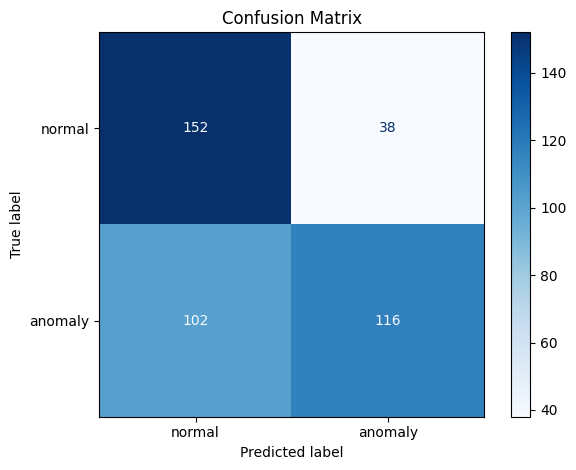

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for features, labels in tqdm(test_loader, desc="Evaluating Model"):
        if torch.cuda.is_available():
            features, labels = features.cuda(), labels.cuda()

        # Get scores for 32 segments, then find the max to represent the video status
        outputs = model(features).squeeze(-1) # (B, 32)
        video_scores = torch.max(outputs, dim=1)[0] # Get maximum anomaly score in the bag
        
        # Predictions: since we output raw logits now, Anomaly is > 0.0 
        preds = (video_scores > 0.0).long()

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

# Generate test predictions
print("\nClassification Report:")
print(classification_report(
    all_true, all_pred,
    labels=[0, 1],
    target_names=["normal", "anomaly"],
    zero_division=0,
    digits=4
))

cm = confusion_matrix(all_true, all_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "anomaly"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


Aggregating Bag Features for Classical ML Diagnosis...
Flattened Train Shape: (1632, 2048)
Training Random Forest Baseline on Flat Features...
Evaluating Random Forest Baseline...

--- RANDOM FOREST DIAGNOSTIC CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      normal     0.7151    0.7000    0.7074       190
     anomaly     0.7432    0.7569    0.7500       218

    accuracy                         0.7304       408
   macro avg     0.7291    0.7284    0.7287       408
weighted avg     0.7301    0.7304    0.7302       408



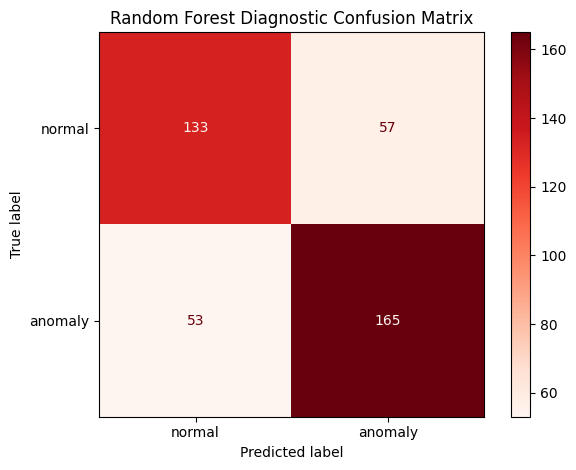

In [25]:
# Let's perform a quick diagnostic to test the "Quality of the Features".
# If our PyTorch models are failing, we can train a robust classical ML baseline (like XGBoost or Random Forest)
# on the exact same features. If even a Random Forest cannot separate Normal from Anomaly, 
# then the problem lies in the Kaggle features themselves (maybe the I3D extraction ignored anomalous frames or lacked spatial resolution).

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

print("Aggregating Bag Features for Classical ML Diagnosis...")
# Combine the 32 segments by taking the mean and max across time, giving us a single 1D vector per video
X_train_mean = np.mean(X_train, axis=1) # (N, 1024)
X_train_max = np.max(X_train, axis=1)   # (N, 1024)
X_train_flat = np.concatenate([X_train_mean, X_train_max], axis=1) # (N, 2048)

X_test_mean = np.mean(X_test, axis=1)
X_test_max = np.max(X_test, axis=1)
X_test_flat = np.concatenate([X_test_mean, X_test_max], axis=1)

print(f"Flattened Train Shape: {X_train_flat.shape}")

# Train a robust classical baseline
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)

print("Training Random Forest Baseline on Flat Features...")
rf.fit(X_train_flat, y_train)

print("Evaluating Random Forest Baseline...")
rf_preds = rf.predict(X_test_flat)

print("\n--- RANDOM FOREST DIAGNOSTIC CLASSIFICATION REPORT ---")
print(classification_report(y_test, rf_preds, target_names=["normal", "anomaly"], digits=4))

cm_rf = confusion_matrix(y_test, rf_preds, labels=[0, 1])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["normal", "anomaly"])
disp_rf.plot(cmap="Reds", values_format="d")
plt.title("Random Forest Diagnostic Confusion Matrix")
plt.tight_layout()
plt.show()

### Inference Pipeline

In [26]:
import numpy as np

def real_time_security_inference(video_path, feature_extractor, classifier, num_segments=32, frames_per_seg=16):
    # 1. Real-time Feature Extraction
    feat = extract_features_from_video(video_path, feature_extractor, num_segments, frames_per_seg)
    if feat is None:
        print("Error: Video corrupted or too short.")
        return
        
    # Apply L2 matching what we did in dataset
    feat_tensor = torch.tensor(feat, dtype=torch.float32)
    feat_tensor = torch.nn.functional.normalize(feat_tensor, p=2, dim=-1)
    feat_tensor = feat_tensor.unsqueeze(0).to(device) # [1, 32, 1024]
    
    classifier.eval()
    with torch.no_grad():
        # Because we built an MLP mapping [B, 32, 1024] -> [B, 32, 1] 
        # Output is segment-level predictions directly 
        logits = classifier(feat_tensor).squeeze(-1).squeeze(0) # [32]
        outputs = torch.sigmoid(logits) # Convert logits to probabilities
        
        # Overall video anomaly prob is max segment score
        anomaly_prob = torch.max(outputs).item()
        
        severity_score = int(np.clip(anomaly_prob * 10, 1, 10)) 
        if severity_score == 0: severity_score = 1
        
        # Segment scores for interpretability
        segment_scores = outputs.cpu().numpy().tolist()
        max_anomaly_segment = np.argmax(segment_scores)
        
        # Calculate approximate timestamp in seconds
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        cap.release()
        
        duration = total_frames / fps
        seg_duration = duration / num_segments
        start_time = max_anomaly_segment * seg_duration
        end_time = (max_anomaly_segment + 1) * seg_duration

        print("="*60)   #Requrement 3 -> Scalable Alerts & Notification
        print("REAL-TIME AI SURVEILLANCE NOTIFICATION")
        print("="*60)
        print(f"Video Source : {os.path.basename(video_path)}")
        
        if severity_score < 4:
            print(f"Status       :NORMAL ROUTINE ACTIVITY")
            print(f"Severity     : {severity_score}/10")
            print("Action       : Filtered - No notification required.")
        else:
            print(f"Status       :UNUSUAL EVENT DETECTED!")
            print(f"Severity     : {severity_score}/10")
            print(f"Explanation  : AI detected sudden behavioral spike between {start_time:.1f}s and {end_time:.1f}s.")
            print("Action       : NOTIFYING SECURITY STAFF IMMEDIATELY.")
        print("="*60)

In [27]:
# taking a random video to test our real-time system on
test_vid = df.sample(n=1).iloc[0]['video_path']
print(f"Testing Pipeline on: {test_vid}")

# This actually runs the AI!
real_time_security_inference(test_vid, i3d_model, model)


Testing Pipeline on: D:\down\AI+FOR+SOCIAL+GOOD+1\Dataset\burglary\Burglary034_x264.mp4
REAL-TIME AI SURVEILLANCE NOTIFICATION
Video Source : Burglary034_x264.mp4
Status       :UNUSUAL EVENT DETECTED!
Severity     : 8/10
Explanation  : AI detected sudden behavioral spike between 25.3s and 26.6s.
Action       : NOTIFYING SECURITY STAFF IMMEDIATELY.


## Inference:
- Random Forest worked really well, the f1 has jumped to 70%
- We hope to improve this further by using a boosting algorithm

## Forward plan

We are trying two boosting models:

1. Hist Gradient Boosting classifier from sklearn
2. XGBoost classifier

Training Boosting Classifier on Flat Features...
Evaluating Boosting Classifier...

--- BOOSTING DIAGNOSTIC CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      normal     0.8000    0.7789    0.7893       190
     anomaly     0.8117    0.8303    0.8209       218

    accuracy                         0.8064       408
   macro avg     0.8058    0.8046    0.8051       408
weighted avg     0.8062    0.8064    0.8062       408



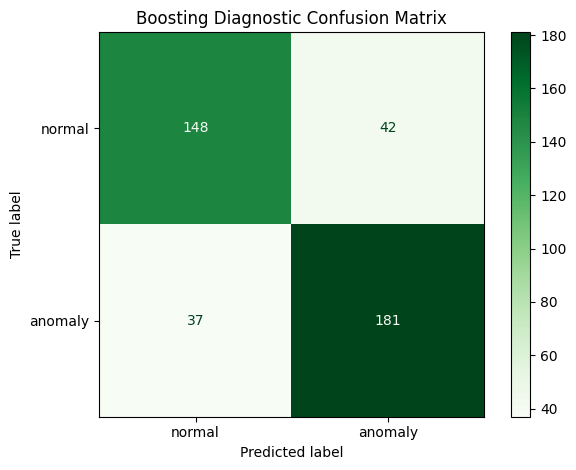

In [28]:
from sklearn.ensemble import HistGradientBoostingClassifier

boosting_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

print("Training Boosting Classifier on Flat Features...")
boosting_model.fit(X_train_flat, y_train)

print("Evaluating Boosting Classifier...")
boost_preds = boosting_model.predict(X_test_flat)

print("\n--- BOOSTING DIAGNOSTIC CLASSIFICATION REPORT ---")
print(classification_report(y_test, boost_preds, target_names=["normal", "anomaly"], digits=4))

cm_boost = confusion_matrix(y_test, boost_preds, labels=[0, 1])
disp_boost = ConfusionMatrixDisplay(confusion_matrix=cm_boost, display_labels=["normal", "anomaly"])
disp_boost.plot(cmap="Greens", values_format="d")
plt.title("Boosting Diagnostic Confusion Matrix")
plt.tight_layout()
plt.show()

In [30]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


XGBoost is installed. Training XGBClassifier...
Training Boosting Classifier on Flat Features...
Evaluating Boosting Classifier...

--- BOOSTING DIAGNOSTIC CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      normal     0.7926    0.7842    0.7884       190
     anomaly     0.8136    0.8211    0.8174       218

    accuracy                         0.8039       408
   macro avg     0.8031    0.8027    0.8029       408
weighted avg     0.8038    0.8039    0.8039       408



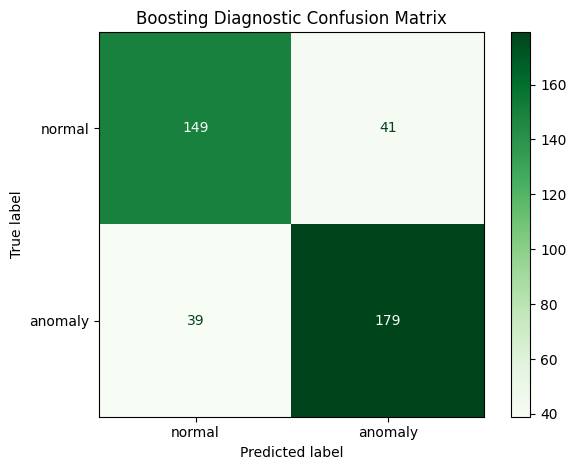

In [31]:
import xgboost as xgb
print("XGBoost is installed. Training XGBClassifier...")

# Calculate scale_pos_weight to handle class imbalance natively
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

boosting_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

print("Training Boosting Classifier on Flat Features...")
boosting_model.fit(X_train_flat, y_train)

print("Evaluating Boosting Classifier...")
boost_preds = boosting_model.predict(X_test_flat)

print("\n--- BOOSTING DIAGNOSTIC CLASSIFICATION REPORT ---")
print(classification_report(y_test, boost_preds, target_names=["normal", "anomaly"], digits=4))

cm_boost = confusion_matrix(y_test, boost_preds, labels=[0, 1])
disp_boost = ConfusionMatrixDisplay(confusion_matrix=cm_boost, display_labels=["normal", "anomaly"])
disp_boost.plot(cmap="Greens", values_format="d")
plt.title("Boosting Diagnostic Confusion Matrix")
plt.tight_layout()
plt.show()

## Inference
An 80% accuracy and f1 is impressive, next step is using ensemble learning to see if we can improve the scores further

Aggregating Enhanced Features (Mean, Max, Min, Std)...
Enhanced Flattened Train Shape: (1632, 4096)
Training Ensemble Classifier on Enhanced Features...
Finding Optimal Threshold...
Optimal Probability Threshold for maximum F1: 0.4113 (Validation F1: 0.8301)

--- ENSEMBLE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      normal     0.8447    0.7158    0.7749       190
     anomaly     0.7814    0.8853    0.8301       218

    accuracy                         0.8064       408
   macro avg     0.8130    0.8006    0.8025       408
weighted avg     0.8109    0.8064    0.8044       408



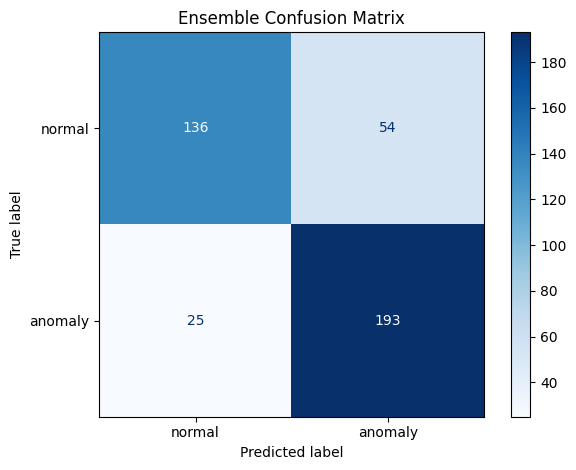

In [32]:
import numpy as np
from sklearn.ensemble import VotingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import matplotlib.pyplot as plt

print("Aggregating Enhanced Features (Mean, Max, Min, Std)...")
# Assuming X_train and X_test are preserved in memory with shape (N, 32, 1024)
X_train_mean = np.mean(X_train, axis=1)
X_train_max = np.max(X_train, axis=1)
X_train_min = np.min(X_train, axis=1)
X_train_std = np.std(X_train, axis=1)
X_train_flat_enhanced = np.concatenate([X_train_mean, X_train_max, X_train_min, X_train_std], axis=1)

X_test_mean = np.mean(X_test, axis=1)
X_test_max = np.max(X_test, axis=1)
X_test_min = np.min(X_test, axis=1)
X_test_std = np.std(X_test, axis=1)
X_test_flat_enhanced = np.concatenate([X_test_mean, X_test_max, X_test_min, X_test_std], axis=1)

print(f"Enhanced Flattened Train Shape: {X_train_flat_enhanced.shape}")

# 1. XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1
xgb_model = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.03, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', n_jobs=-1
)

# 2. Histogram Gradient Boosting
hgb_model = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.03, max_depth=7,
    l2_regularization=0.1, random_state=42
)

# 3. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced', 
    random_state=42, n_jobs=-1
)

# Ensemble with Soft Voting (averages the probabilities)
ensemble = VotingClassifier(
    estimators=[('xgb', xgb_model), ('hgb', hgb_model), ('rf', rf_model)],
    voting='soft',
    weights=[2, 2, 1] # Give more weight to the boosting models
)

print("Training Ensemble Classifier on Enhanced Features...")
ensemble.fit(X_train_flat_enhanced, y_train)

print("Finding Optimal Threshold...")
probas = ensemble.predict_proba(X_test_flat_enhanced)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probas)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"Optimal Probability Threshold for maximum F1: {best_threshold:.4f} (Validation F1: {best_f1:.4f})")

# Apply optimal threshold
ensemble_preds = (probas >= best_threshold).astype(int)

print("\n--- ENSEMBLE CLASSIFICATION REPORT ---")
print(classification_report(y_test, ensemble_preds, target_names=["normal", "anomaly"], digits=4))

cm_ens = confusion_matrix(y_test, ensemble_preds, labels=[0, 1])
disp_ens = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=["normal", "anomaly"])
disp_ens.plot(cmap="Blues", values_format="d")
plt.title("Ensemble Confusion Matrix")
plt.tight_layout()
plt.show()

## Final Inference

- We have achieved ~80% accuracy, precision, recall and F1 scores.
- We used classic ML models for it, and I would say this is the best we can achieve through this means
- **Next Steps:** To go from 80 to 90, the most promising method would be using **Temporal Deep Learning**
- **Temporal Deep Learning** deals with the analysis of data that changes over time. Which is exactly the right example of our dataset
- **Why did we not implement it?** This project is being made in time constraints of a hackathon. It takes time for the model to train, ranging from a few hours at least to over a day, and we did not have enough time, hence the team decided to not do it.
